<a href="https://colab.research.google.com/github/Fariha-Abdullah/Basic-Python-Projects/blob/main/Copy_of_Copy_of_Copy_of_CSE425_PROJECT_(4).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q pretty_midi music21 numpy matplotlib tqdm pandas
!pip install -q torch torchvision torchaudio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 52.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 5.4 MB/s eta 0:00:00


In [2]:
import os
import glob
import math
import random
import numpy as np
import pandas as pd
import pretty_midi
import matplotlib.pyplot as plt

from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
!wget -O maestro-v3.0.0-midi.zip https://storage.googleapis.com/magentadata/datasets/maestro/v3.0.0/maestro-v3.0.0-midi.zip
!unzip -q maestro-v3.0.0-midi.zip

--2026-04-24 09:20:03--  https://storage.googleapis.com/magentadata/datasets/maestro/v3.0.0/maestro-v3.0.0-midi.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 173.194.216.207, 173.194.217.207, 108.177.11.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|173.194.216.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 58416533 (56M) [application/octet-stream]
Saving to: ‘maestro-v3.0.0-midi.zip’

maestro-v3.0.0-midi 100%[===================>]  55.71M   146MB/s    in 0.4s    

2026-04-24 09:20:04 (146 MB/s) - ‘maestro-v3.0.0-midi.zip’ saved [58416533/58416533]



In [5]:
DATASET_PATH = "/content/maestro-v3.0.0"

midi_files = glob.glob(os.path.join(DATASET_PATH, "**/*.midi"), recursive=True)
midi_files = sorted(midi_files)

print("Total MIDI files found:", len(midi_files))
print("First 5 files:")
for f in midi_files[:5]:
    print(f)

Total MIDI files found: 1276
First 5 files:
/content/maestro-v3.0.0/2004/MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_05_Track05_wav.midi
/content/maestro-v3.0.0/2004/MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_06_Track06_wav.midi
/content/maestro-v3.0.0/2004/MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_08_Track08_wav.midi
/content/maestro-v3.0.0/2004/MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_10_Track10_wav.midi
/content/maestro-v3.0.0/2004/MIDI-Unprocessed_SMF_05_R1_2004_01_ORIG_MID--AUDIO_05_R1_2004_02_Track02_wav.midi


In [6]:
SEQ_LEN = 64
STRIDE = 32
FS = 8
MIN_PITCH = 21
MAX_PITCH = 108
PITCH_DIM = MAX_PITCH - MIN_PITCH + 1

MAX_SEQUENCES_PER_GENRE = 3000
MIN_ACTIVE_NOTES = 12

BATCH_SIZE = 32
HIDDEN_DIM = 256
LATENT_DIM = 128
NUM_LAYERS = 2
DROPOUT = 0.2
LEARNING_RATE = 1e-3
EPOCHS = 35
PATIENCE = 7

GENRE_EMBED_DIM = 16
BETA_MAX = 0.1

OUTPUT_DIR = "/content/outputs_task2_vae"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("PITCH_DIM =", PITCH_DIM)

PITCH_DIM = 88


In [7]:
def midi_to_pianoroll(midi_path, fs=FS, min_pitch=MIN_PITCH, max_pitch=MAX_PITCH):
    try:
        midi_data = pretty_midi.PrettyMIDI(midi_path)
        piano_roll = midi_data.get_piano_roll(fs=fs)  # (128, time)

        # keep only piano range
        piano_roll = piano_roll[min_pitch:max_pitch + 1, :]

        # binarize note activations
        piano_roll = (piano_roll > 0).astype(np.float32)

        # transpose to (time, pitch)
        piano_roll = piano_roll.T
        return piano_roll

    except Exception as e:
        print(f"Error processing {midi_path}: {e}")
        return None

In [8]:
def create_sequences(piano_roll, seq_len=SEQ_LEN, stride=STRIDE, min_active_notes=MIN_ACTIVE_NOTES):
    sequences = []
    total_steps = len(piano_roll)

    if total_steps < seq_len:
        return sequences

    for i in range(0, total_steps - seq_len + 1, stride):
        seq = piano_roll[i:i + seq_len]

        if np.sum(seq) < min_active_notes:
            continue

        sequences.append(seq.astype(np.float32))

    return sequences

In [9]:
all_sequences = []
used_files = 0
MAX_SEQUENCES = 3000  # limit total number of sequences

for midi_path in tqdm(midi_files, desc="Processing MIDI files"):
    piano_roll = midi_to_pianoroll(midi_path)

    if piano_roll is None:
        continue

    seqs = create_sequences(piano_roll)

    if len(seqs) > 0:
        used_files += 1

    for seq in seqs:
        all_sequences.append(seq)

        if len(all_sequences) >= MAX_SEQUENCES:
            break

    if len(all_sequences) >= MAX_SEQUENCES:
        break

all_sequences = np.array(all_sequences, dtype=np.float32)

print("Total usable sequences:", len(all_sequences))
print("Files used:", used_files)
print("Dataset shape:", all_sequences.shape)

Processing MIDI files:   1%|▏         | 18/1276 [00:12<14:50,  1.41it/s]

Total usable sequences: 3000
Files used: 19
Dataset shape: (3000, 64, 88)


In [10]:
indices = np.arange(len(all_sequences))
np.random.shuffle(indices)

all_sequences = all_sequences[indices]

train_size = int(0.8 * len(all_sequences))
val_size = int(0.1 * len(all_sequences))

train_data = all_sequences[:train_size]
val_data = all_sequences[train_size:train_size + val_size]
test_data = all_sequences[train_size + val_size:]

print("Train:", train_data.shape)
print("Val:", val_data.shape)
print("Test:", test_data.shape)

Train: (2400, 64, 88)
Val: (300, 64, 88)
Test: (300, 64, 88)


In [11]:
class MusicDataset(Dataset):
    def __init__(self, data):
        self.data = torch.tensor(data, dtype=torch.float32)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x = self.data[idx]
        return x, x  # autoencoder target = input


train_dataset = MusicDataset(train_data)
val_dataset = MusicDataset(val_data)
test_dataset = MusicDataset(test_data)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 75
Val batches: 10
Test batches: 10


In [12]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim=PITCH_DIM, hidden_dim=HIDDEN_DIM, latent_dim=LATENT_DIM,
                 num_layers=NUM_LAYERS, dropout=DROPOUT):
        super().__init__()

        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.num_layers = num_layers

        self.encoder_lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True
        )

        self.fc_latent = nn.Linear(hidden_dim, latent_dim)

        self.fc_h = nn.Linear(latent_dim, hidden_dim * num_layers)
        self.fc_c = nn.Linear(latent_dim, hidden_dim * num_layers)

        self.decoder_lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True
        )

        self.output_layer = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        _, (h_n, _) = self.encoder_lstm(x)
        h_last = h_n[-1]
        z = self.fc_latent(h_last)
        return z

    def decode(self, z, seq_len):
        batch_size = z.size(0)

        h0 = self.fc_h(z).view(self.num_layers, batch_size, self.hidden_dim)
        c0 = self.fc_c(z).view(self.num_layers, batch_size, self.hidden_dim)

        decoder_input = torch.zeros(batch_size, seq_len, self.input_dim, device=z.device)
        decoded_seq, _ = self.decoder_lstm(decoder_input, (h0, c0))

        logits = self.output_layer(decoded_seq)
        return logits

    def forward(self, x):
        z = self.encode(x)
        logits = self.decode(z, x.size(1))
        return logits

In [13]:
model = LSTMAutoencoder().to(device)

pos_weight = torch.full((PITCH_DIM,), 4.0).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(model)

LSTMAutoencoder(
  (encoder_lstm): LSTM(88, 256, num_layers=2, batch_first=True, dropout=0.2)
  (fc_latent): Linear(in_features=256, out_features=128, bias=True)
  (fc_h): Linear(in_features=128, out_features=512, bias=True)
  (fc_c): Linear(in_features=128, out_features=512, bias=True)
  (decoder_lstm): LSTM(88, 256, num_layers=2, batch_first=True, dropout=0.2)
  (output_layer): Linear(in_features=256, out_features=88, bias=True)
)


In [14]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        recon = model(x)
        loss = criterion(recon, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            recon = model(x)
            loss = criterion(recon, y)
            total_loss += loss.item()

    return total_loss / len(loader)

In [15]:
train_losses = []
val_losses = []
best_val_loss = float("inf")
best_model_path = os.path.join(OUTPUT_DIR, "best_lstm_autoencoder.pt")
patience_counter = 0

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = validate_one_epoch(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)
        patience_counter = 0
    else:
        patience_counter += 1

    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if patience_counter >= PATIENCE:
        print("Early stopping triggered.")
        break

print("Best validation loss:", best_val_loss)
print("Saved best model to:", best_model_path)

Epoch [1/35] | Train Loss: 0.5119 | Val Loss: 0.4458
Epoch [2/35] | Train Loss: 0.4742 | Val Loss: 0.4442
Epoch [3/35] | Train Loss: 0.4741 | Val Loss: 0.4441
Epoch [4/35] | Train Loss: 0.4737 | Val Loss: 0.4443
Epoch [5/35] | Train Loss: 0.4735 | Val Loss: 0.4460
Epoch [6/35] | Train Loss: 0.4737 | Val Loss: 0.4462
Epoch [7/35] | Train Loss: 0.4738 | Val Loss: 0.4434
Epoch [8/35] | Train Loss: 0.4732 | Val Loss: 0.4460
Epoch [9/35] | Train Loss: 0.4733 | Val Loss: 0.4434
Epoch [10/35] | Train Loss: 0.4734 | Val Loss: 0.4444
Epoch [11/35] | Train Loss: 0.4733 | Val Loss: 0.4445
Epoch [12/35] | Train Loss: 0.4732 | Val Loss: 0.4427
Epoch [13/35] | Train Loss: 0.4732 | Val Loss: 0.4429
Epoch [14/35] | Train Loss: 0.4734 | Val Loss: 0.4435
Epoch [15/35] | Train Loss: 0.4732 | Val Loss: 0.4467
Epoch [16/35] | Train Loss: 0.4732 | Val Loss: 0.4429
Epoch [17/35] | Train Loss: 0.4731 | Val Loss: 0.4447
Epoch [18/35] | Train Loss: 0.4732 | Val Loss: 0.4437
Epoch [19/35] | Train Loss: 0.4728 | 

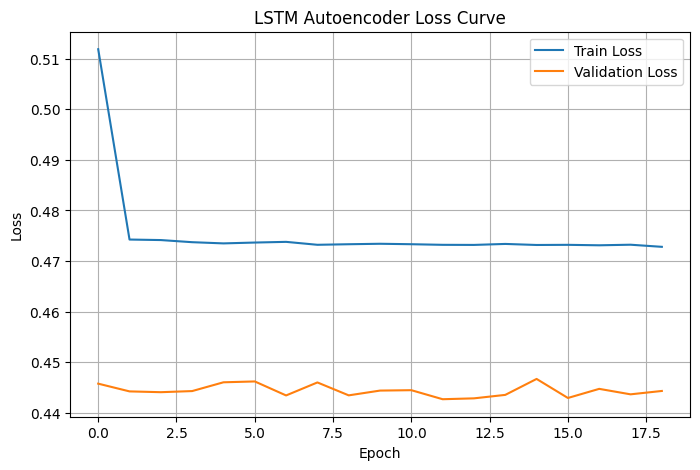

Saved loss plot to: /content/outputs_task2_vae/loss_curve_task1.png


In [16]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Autoencoder Loss Curve")
plt.legend()
plt.grid(True)

loss_plot_path = os.path.join(OUTPUT_DIR, "loss_curve_task1.png")
plt.savefig(loss_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved loss plot to:", loss_plot_path)

In [17]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()
print("Best model loaded.")

Best model loaded.


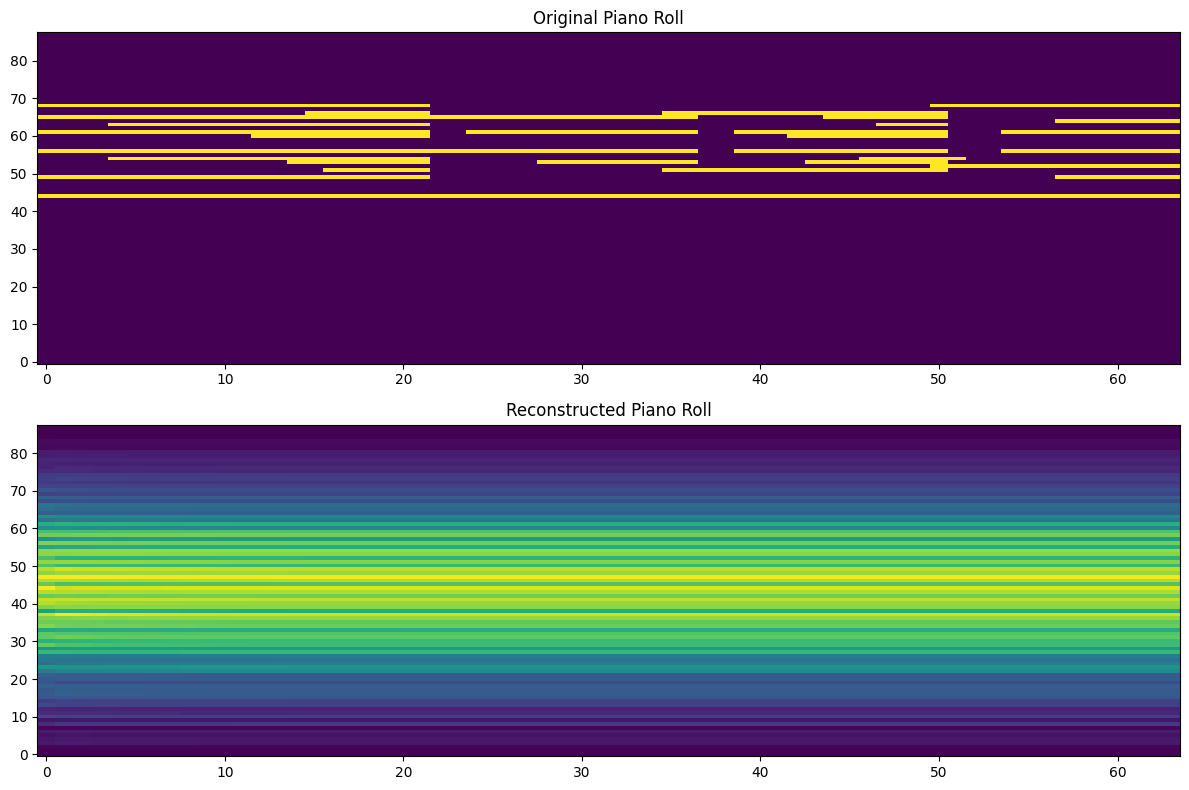

In [18]:
x_batch, _ = next(iter(test_loader))
x_batch = x_batch.to(device)

with torch.no_grad():
    recon_batch = torch.sigmoid(model(x_batch))

original = x_batch[0].cpu().numpy()
reconstructed = recon_batch[0].cpu().numpy()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].imshow(original.T, aspect='auto', origin='lower')
axes[0].set_title("Original Piano Roll")

axes[1].imshow(reconstructed.T, aspect='auto', origin='lower')
axes[1].set_title("Reconstructed Piano Roll")

plt.tight_layout()
plt.show()

In [19]:
def binarize_pianoroll(piano_roll, threshold=0.5, max_polyphony=6, min_keep_prob=0.35):
    pr = np.array(piano_roll, copy=True)
    binary_roll = np.zeros_like(pr, dtype=np.int32)

    for t in range(pr.shape[0]):
        row = pr[t]

        active = np.where(row >= threshold)[0]

        if len(active) == 0:
            best_idx = np.argmax(row)
            if row[best_idx] >= min_keep_prob:
                active = np.array([best_idx])

        if len(active) > max_polyphony:
            active = active[np.argsort(row[active])[-max_polyphony:]]

        binary_roll[t, active] = 1

    return binary_roll


def pianoroll_to_midi(piano_roll, output_path, fs=FS, min_pitch=MIN_PITCH,
                      threshold=0.5, max_polyphony=6, min_keep_prob=0.35):

    binary_roll = binarize_pianoroll(
        piano_roll,
        threshold=threshold,
        max_polyphony=max_polyphony,
        min_keep_prob=min_keep_prob
    )

    pm = pretty_midi.PrettyMIDI()
    instrument = pretty_midi.Instrument(program=0)
    time_per_step = 1.0 / fs

    for pitch_idx in range(binary_roll.shape[1]):
        pitch = pitch_idx + min_pitch
        note_on = None

        for t in range(binary_roll.shape[0]):
            value = binary_roll[t, pitch_idx]

            if value == 1 and note_on is None:
                note_on = t * time_per_step

            elif value == 0 and note_on is not None:
                note_off = t * time_per_step
                if note_off > note_on:
                    instrument.notes.append(
                        pretty_midi.Note(
                            velocity=100,
                            pitch=pitch,
                            start=note_on,
                            end=note_off
                        )
                    )
                note_on = None

        if note_on is not None:
            note_off = binary_roll.shape[0] * time_per_step
            if note_off > note_on:
                instrument.notes.append(
                    pretty_midi.Note(
                        velocity=100,
                        pitch=pitch,
                        start=note_on,
                        end=note_off
                    )
                )

    pm.instruments.append(instrument)
    pm.write(output_path)

    return binary_roll

In [20]:
recon_dir = os.path.join(OUTPUT_DIR, "generated_midis_task1_reconstructed")
os.makedirs(recon_dir, exist_ok=True)

saved = 0
for i in range(len(test_data)):
    x = torch.tensor(test_data[i], dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        recon = torch.sigmoid(model(x)).squeeze(0).cpu().numpy()

    out_path = os.path.join(recon_dir, f"reconstructed_{saved+1}.mid")
    pianoroll_to_midi(recon, out_path, threshold=0.5, max_polyphony=6)

    saved += 1
    if saved == 5:
        break

print("Saved 5 reconstructed MIDI files to:", recon_dir)

Saved 5 reconstructed MIDI files to: /content/outputs_task2_vae/generated_midis_task1_reconstructed


In [21]:
def generate_from_latent(model, source_loader, num_samples=5, seq_len=SEQ_LEN, noise_std=0.15):
    model.eval()

    latent_bank = []

    with torch.no_grad():
        for x, _ in source_loader:
            x = x.to(device)
            z = model.encode(x)
            latent_bank.append(z.cpu())

            if sum(chunk.size(0) for chunk in latent_bank) >= 256:
                break

    latent_bank = torch.cat(latent_bank, dim=0)

    idx = torch.randint(0, latent_bank.size(0), (num_samples,))
    z = latent_bank[idx].to(device)
    z = z + noise_std * torch.randn_like(z)

    with torch.no_grad():
        samples = torch.sigmoid(model.decode(z, seq_len)).cpu().numpy()

    return samples

In [22]:
sampled_dir = os.path.join(OUTPUT_DIR, "generated_midis_task1_sampled")
os.makedirs(sampled_dir, exist_ok=True)

generated_samples = generate_from_latent(model, train_loader, num_samples=5)

for i, sample in enumerate(generated_samples):
    out_path = os.path.join(sampled_dir, f"generated_{i+1}.mid")
    pianoroll_to_midi(sample, out_path, threshold=0.5, max_polyphony=6)

print("Saved 5 generated MIDI files to:", sampled_dir)

Saved 5 generated MIDI files to: /content/outputs_task2_vae/generated_midis_task1_sampled


In [23]:
test_loss = validate_one_epoch(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}")

Test Loss: 0.4934


In [24]:
def compute_pitch_class_histogram(piano_roll, min_pitch=MIN_PITCH):
    piano_roll = (piano_roll > 0).astype(np.int32)
    pitch_activity = np.sum(piano_roll, axis=0).astype(np.float64)

    hist = np.zeros(12, dtype=np.float64)
    for i, value in enumerate(pitch_activity):
        midi_pitch = min_pitch + i
        pitch_class = midi_pitch % 12
        hist[pitch_class] += value

    total = np.sum(hist)
    if total > 0:
        hist /= total

    return hist


def histogram_distance(h1, h2):
    return np.sum(np.abs(h1 - h2))


real_seq = test_data[0]
gen_seq = generated_samples[0]

gen_binary = binarize_pianoroll(gen_seq, threshold=0.5, max_polyphony=6)

real_hist = compute_pitch_class_histogram(real_seq)
gen_hist = compute_pitch_class_histogram(gen_binary)

pitch_hist_distance = histogram_distance(real_hist, gen_hist)
print("Pitch Histogram Distance:", round(float(pitch_hist_distance), 4))

Pitch Histogram Distance: 2.0


In [25]:
def rhythm_diversity_score(piano_roll):
    piano_roll = (piano_roll > 0).astype(np.int32)
    durations = []

    for pitch_idx in range(piano_roll.shape[1]):
        current_duration = 0
        for t in range(piano_roll.shape[0]):
            if piano_roll[t, pitch_idx] == 1:
                current_duration += 1
            elif current_duration > 0:
                durations.append(current_duration)
                current_duration = 0

        if current_duration > 0:
            durations.append(current_duration)

    if len(durations) == 0:
        return 0.0

    return len(set(durations)) / len(durations)

real_rhythm_div = rhythm_diversity_score(real_seq)
gen_rhythm_div = rhythm_diversity_score(gen_binary)

print("Real Rhythm Diversity:", round(real_rhythm_div, 4))
print("Generated Rhythm Diversity:", round(gen_rhythm_div, 4))

Real Rhythm Diversity: 0.4828
Generated Rhythm Diversity: 1.0


In [26]:
def repetition_ratio(piano_roll, pattern_len=4):
    piano_roll = (piano_roll > 0).astype(np.int32)
    patterns = []

    for i in range(0, len(piano_roll) - pattern_len + 1):
        pattern = tuple(piano_roll[i:i+pattern_len].flatten().tolist())
        patterns.append(pattern)

    if len(patterns) == 0:
        return 0.0

    unique_patterns = len(set(patterns))
    repeated_patterns = len(patterns) - unique_patterns

    return repeated_patterns / len(patterns)

real_rep = repetition_ratio(real_seq)
gen_rep = repetition_ratio(gen_binary)

print("Real Repetition Ratio:", round(real_rep, 4))
print("Generated Repetition Ratio:", round(gen_rep, 4))

Real Repetition Ratio: 0.1967
Generated Repetition Ratio: 0.9836


In [27]:
results = pd.DataFrame([
    {
        "Model": "LSTM Autoencoder",
        "Test Loss": float(test_loss),
        "Pitch Histogram Distance": float(pitch_hist_distance),
        "Generated Rhythm Diversity": float(gen_rhythm_div),
        "Generated Repetition Ratio": float(gen_rep)
    }
])

metrics_csv_path = os.path.join(OUTPUT_DIR, "task1_metrics.csv")
results.to_csv(metrics_csv_path, index=False)

print(results)
print("Saved metrics to:", metrics_csv_path)

              Model  Test Loss  Pitch Histogram Distance  \
0  LSTM Autoencoder   0.493355                       2.0   

   Generated Rhythm Diversity  Generated Repetition Ratio  
0                         1.0                    0.983607  
Saved metrics to: /content/outputs_task2_vae/task1_metrics.csv


In [28]:
!zip -r /content/task1_outputs_fixed.zip /content/outputs_task1_fixed > /dev/null
print("Created: /content/task1_outputs_fixed.zip")

Created: /content/task1_outputs_fixed.zip


In [29]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Task2**

In [30]:
GENRE_FOLDERS = {
    "classical": "/content/task2_data/classical",
    "jazz": "/content/task2_data/jazz",
    "pop": "/content/task2_data/pop",
    "rock": "/content/task2_data/rock",
}

In [31]:
SEQ_LEN = 32
STRIDE = 16
FS = 8

MIN_PITCH = 21
MAX_PITCH = 108
PITCH_DIM = MAX_PITCH - MIN_PITCH + 1

MAX_SEQUENCES_PER_GENRE = 500
MIN_ACTIVE_NOTES = 4

In [32]:
import os
import glob

files = glob.glob(os.path.join("/content/maestro-v3.0.0", "**", "*.midi"), recursive=True)
files = sorted(files)

print("Number of MIDI files:", len(files))
print("First file:", files[0])

sample_file = files[0]
pr = midi_to_pianoroll(sample_file)

print("piano_roll is None?", pr is None)
if pr is not None:
    print("piano_roll shape:", pr.shape)
    print("sum of notes:", np.sum(pr))

Number of MIDI files: 1276
First file: /content/maestro-v3.0.0/2004/MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_05_Track05_wav.midi
piano_roll is None? False
piano_roll shape: (7752, 88)
sum of notes: 17803.0


In [33]:
seqs = create_sequences(pr, seq_len=SEQ_LEN, stride=STRIDE, min_active_notes=MIN_ACTIVE_NOTES)

print("Number of sequences from one file:", len(seqs))
if len(seqs) > 0:
    print("One sequence shape:", seqs[0].shape)
    print("Sequence sum:", np.sum(seqs[0]))

Number of sequences from one file: 483
One sequence shape: (32, 88)
Sequence sum: 70.0


In [34]:
all_sequences = []
all_labels = []
used_files = {g: 0 for g in GENRE_FOLDERS}

for genre, folder in GENRE_FOLDERS.items():
    files = glob.glob(os.path.join(folder, "**", "*.mid"), recursive=True)
    files += glob.glob(os.path.join(folder, "**", "*.midi"), recursive=True)
    files = sorted(list(set(files)))

    print(f"\nProcessing genre: {genre}")
    print(f"Found files: {len(files)}")

    collected = 0

    for midi_path in files:
        piano_roll = midi_to_pianoroll(midi_path)

        if piano_roll is None:
            continue

        seqs = create_sequences(
            piano_roll,
            seq_len=SEQ_LEN,
            stride=STRIDE,
            min_active_notes=MIN_ACTIVE_NOTES
        )

        if len(seqs) > 0:
            used_files[genre] += 1

        for seq in seqs:
            all_sequences.append(seq)
            all_labels.append(genre_to_id[genre])
            collected += 1

            if collected >= MAX_SEQUENCES_PER_GENRE:
                break

        if collected >= MAX_SEQUENCES_PER_GENRE:
            break

    print(f"Collected sequences for {genre}: {collected}")

all_sequences = np.array(all_sequences, dtype=np.float32)
all_labels = np.array(all_labels, dtype=np.int64)

print("\n========== FINAL DATASET CHECK ==========")
print("Total sequences:", len(all_sequences))
print("all_sequences shape:", all_sequences.shape)
print("all_labels shape:", all_labels.shape)
print("Used files per genre:", used_files)


Processing genre: classical
Found files: 0
Collected sequences for classical: 0

Processing genre: jazz
Found files: 0
Collected sequences for jazz: 0

Processing genre: pop
Found files: 0
Collected sequences for pop: 0

Processing genre: rock
Found files: 0
Collected sequences for rock: 0

========== FINAL DATASET CHECK ==========
Total sequences: 0
all_sequences shape: (0,)
all_labels shape: (0,)
Used files per genre: {'classical': 0, 'jazz': 0, 'pop': 0, 'rock': 0}


In [35]:
print("piano_roll is None?", pr is None)
print("Number of sequences from one file:", len(seqs))
print("Total sequences:", len(all_sequences))

piano_roll is None? False
Number of sequences from one file: 483
Total sequences: 0


In [36]:
!mkdir -p /content/task2_data/classical
!mkdir -p /content/task2_data/jazz
!mkdir -p /content/task2_data/pop
!mkdir -p /content/task2_data/rock

In [37]:
!wget -O /content/groove-v1.0.0-midionly.zip \
https://storage.googleapis.com/magentadata/datasets/groove/groove-v1.0.0-midionly.zip

--2026-04-24 09:21:35--  https://storage.googleapis.com/magentadata/datasets/groove/groove-v1.0.0-midionly.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 173.194.215.207, 173.194.216.207, 173.194.217.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|173.194.215.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3260318 (3.1M) [application/zip]
Saving to: ‘/content/groove-v1.0.0-midionly.zip’

/content/groove-v1. 100%[===================>]   3.11M  --.-KB/s    in 0.02s   

2026-04-24 09:21:35 (194 MB/s) - ‘/content/groove-v1.0.0-midionly.zip’ saved [3260318/3260318]



In [38]:
!mkdir -p /content/groove_raw
!unzip -q /content/groove-v1.0.0-midionly.zip -d /content/groove_raw

In [39]:
!find /content/maestro-v3.0.0 -iname "*.midi" | head -300 | xargs -I {} cp "{}" /content/task2_data/classical/

In [40]:
import os
import glob
import shutil
import pandas as pd

# Find metadata
info_files = glob.glob("/content/groove_raw/**/info.csv", recursive=True)
print("info.csv files found:", info_files)

groove_info = info_files[0]
groove_root = os.path.dirname(groove_info)

df = pd.read_csv(groove_info)

# Main style label
df["primary_style"] = df["style"].str.split("/").str[0]

# Make sure destination folders exist
for style in ["jazz", "pop", "rock"]:
    os.makedirs(f"/content/task2_data/{style}", exist_ok=True)

for style in ["jazz", "pop", "rock"]:
    subset = df[df["primary_style"] == style].copy()
    print(style, "rows in metadata:", len(subset))

    copied = 0
    for _, row in subset.iterrows():
        src = os.path.join(groove_root, row["midi_filename"])

        # make safe flat filename
        safe_name = str(row["id"]).replace("/", "_").replace("\\", "_")
        dst = f"/content/task2_data/{style}/{safe_name}.mid"

        if os.path.exists(src):
            shutil.copy2(src, dst)
            copied += 1

    print(style, "copied files:", copied)

info.csv files found: ['/content/groove_raw/groove/info.csv']
jazz rows in metadata: 101
jazz copied files: 101
pop rows in metadata: 27
pop copied files: 27
rock rows in metadata: 341
rock copied files: 341


In [41]:
import glob
import os

GENRE_FOLDERS = {
    "classical": "/content/task2_data/classical",
    "jazz": "/content/task2_data/jazz",
    "pop": "/content/task2_data/pop",
    "rock": "/content/task2_data/rock",
}

for genre, folder in GENRE_FOLDERS.items():
    files = glob.glob(os.path.join(folder, "*.mid"))
    files += glob.glob(os.path.join(folder, "*.midi"))
    print(genre, len(files))
    if files:
        print(" first file:", files[0])

classical 300
 first file: /content/task2_data/classical/MIDI-Unprocessed_12_R1_2006_01-08_ORIG_MID--AUDIO_12_R1_2006_06_Track06_wav.midi
jazz 101
 first file: /content/task2_data/jazz/drummer1_session1_57.mid
pop 27
 first file: /content/task2_data/pop/drummer7_eval_session_7.mid
rock 341
 first file: /content/task2_data/rock/drummer3_session2_20.mid


In [42]:
def midi_to_pianoroll(midi_path, fs=FS, min_pitch=MIN_PITCH, max_pitch=MAX_PITCH):
    try:
        pm = pretty_midi.PrettyMIDI(midi_path)

        if len(pm.instruments) == 0:
            return None

        end_time = pm.get_end_time()
        if end_time <= 0:
            return None

        n_steps = int(np.ceil(end_time * fs)) + 1
        piano_roll = np.zeros((n_steps, 128), dtype=np.float32)

        for inst in pm.instruments:
            for note in inst.notes:
                pitch = note.pitch

                if pitch < min_pitch or pitch > max_pitch:
                    continue

                start_step = int(np.floor(note.start * fs))
                end_step = int(np.ceil(note.end * fs))

                # very important for drum / short notes
                if end_step <= start_step:
                    end_step = start_step + 1

                piano_roll[start_step:end_step, pitch] = 1.0

        piano_roll = piano_roll[:, min_pitch:max_pitch + 1]

        if piano_roll.shape[0] == 0 or np.sum(piano_roll) == 0:
            return None

        return piano_roll

    except Exception as e:
        print("Error in", midi_path, ":", e)
        return None

In [43]:
SEQ_LEN = 32
STRIDE = 16
FS = 8

MIN_PITCH = 21
MAX_PITCH = 108
PITCH_DIM = MAX_PITCH - MIN_PITCH + 1

MAX_SEQUENCES_PER_GENRE = 500
MIN_ACTIVE_NOTES = 1

In [44]:
GENRE_FOLDERS = {
    "classical": "/content/task2_data/classical",
    "jazz": "/content/task2_data/jazz",
    "pop": "/content/task2_data/pop",
    "rock": "/content/task2_data/rock",
}

genre_to_id = {
    "classical": 0,
    "jazz": 1,
    "pop": 2,
    "rock": 3,
}

id_to_genre = {v: k for k, v in genre_to_id.items()}
NUM_GENRES = len(genre_to_id)

print(genre_to_id)
print("NUM_GENRES =", NUM_GENRES)

{'classical': 0, 'jazz': 1, 'pop': 2, 'rock': 3}
NUM_GENRES = 4


In [45]:
import glob
import numpy as np

jazz_files = glob.glob("/content/task2_data/jazz/*.mid") + glob.glob("/content/task2_data/jazz/*.midi")
jazz_files = sorted(jazz_files)

print("Jazz files:", len(jazz_files))
print("First jazz file:", jazz_files[0])

test_jazz = jazz_files[0]
pr_jazz = midi_to_pianoroll(test_jazz)

print("pr_jazz is None?", pr_jazz is None)
if pr_jazz is not None:
    print("pr_jazz shape:", pr_jazz.shape)
    print("sum of notes:", np.sum(pr_jazz))

Jazz files: 101
First jazz file: /content/task2_data/jazz/drummer10_session1_1.mid
pr_jazz is None? False
pr_jazz shape: (1316, 88)
sum of notes: 1905.0


In [46]:
seqs_jazz = create_sequences(
    pr_jazz,
    seq_len=SEQ_LEN,
    stride=STRIDE,
    min_active_notes=MIN_ACTIVE_NOTES
)

print("Number of jazz sequences from one file:", len(seqs_jazz))
if len(seqs_jazz) > 0:
    print("One sequence shape:", seqs_jazz[0].shape)
    print("Sequence sum:", np.sum(seqs_jazz[0]))

Number of jazz sequences from one file: 81
One sequence shape: (32, 88)
Sequence sum: 32.0


In [47]:
all_sequences = []
all_labels = []
used_files = {g: 0 for g in GENRE_FOLDERS}

MAX_SEQUENCES_PER_GENRE = 500

for genre, folder in GENRE_FOLDERS.items():
    files = glob.glob(os.path.join(folder, "*.mid"))
    files += glob.glob(os.path.join(folder, "*.midi"))
    files = sorted(list(set(files)))

    print(f"\nProcessing genre: {genre}")
    print(f"Found files: {len(files)}")

    collected = 0

    for midi_path in files:
        piano_roll = midi_to_pianoroll(midi_path)

        if piano_roll is None:
            continue

        seqs = create_sequences(
            piano_roll,
            seq_len=SEQ_LEN,
            stride=STRIDE,
            min_active_notes=MIN_ACTIVE_NOTES
        )

        if len(seqs) > 0:
            used_files[genre] += 1

        for seq in seqs:
            all_sequences.append(seq)
            all_labels.append(genre_to_id[genre])
            collected += 1

            if collected >= MAX_SEQUENCES_PER_GENRE:
                break

        if collected >= MAX_SEQUENCES_PER_GENRE:
            break

    print(f"Collected sequences for {genre}: {collected}")

all_sequences = np.array(all_sequences, dtype=np.float32)
all_labels = np.array(all_labels, dtype=np.int64)

print("\n========== FINAL DATASET CHECK ==========")
print("Total sequences:", len(all_sequences))
print("all_sequences shape:", all_sequences.shape)
print("all_labels shape:", all_labels.shape)
print("Used files per genre:", used_files)
print("Label counts:", pd.Series(all_labels).value_counts().sort_index().to_dict())


Processing genre: classical
Found files: 300
Collected sequences for classical: 500

Processing genre: jazz
Found files: 101
Collected sequences for jazz: 500

Processing genre: pop
Found files: 27
Collected sequences for pop: 306

Processing genre: rock
Found files: 341
Collected sequences for rock: 500

========== FINAL DATASET CHECK ==========
Total sequences: 1806
all_sequences shape: (1806, 32, 88)
all_labels shape: (1806,)
Used files per genre: {'classical': 3, 'jazz': 17, 'pop': 20, 'rock': 22}
Label counts: {0: 500, 1: 500, 2: 306, 3: 500}


In [48]:
from sklearn.model_selection import train_test_split

train_data_full, test_data, train_labels_full, test_labels = train_test_split(
    all_sequences,
    all_labels,
    test_size=0.1,
    random_state=42,
    stratify=all_labels
)

train_data, val_data, train_labels, val_labels = train_test_split(
    train_data_full,
    train_labels_full,
    test_size=0.1111111111,
    random_state=42,
    stratify=train_labels_full
)

print("Train:", train_data.shape, train_labels.shape)
print("Val:", val_data.shape, val_labels.shape)
print("Test:", test_data.shape, test_labels.shape)

Train: (1444, 32, 88) (1444,)
Val: (181, 32, 88) (181,)
Test: (181, 32, 88) (181,)


In [49]:
from torch.utils.data import Dataset, DataLoader
import torch

class MusicDataset(Dataset):
    def __init__(self, data, labels):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x = self.data[idx]
        g = self.labels[idx]
        return x, g

BATCH_SIZE = 32

train_dataset = MusicDataset(train_data, train_labels)
val_dataset = MusicDataset(val_data, val_labels)
test_dataset = MusicDataset(test_data, test_labels)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 46
Val batches: 6
Test batches: 6


In [50]:
import os
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

HIDDEN_DIM = 256
LATENT_DIM = 128
NUM_LAYERS = 2
DROPOUT = 0.2
LEARNING_RATE = 1e-3
EPOCHS = 20
PATIENCE = 5
GENRE_EMBED_DIM = 16
BETA_MAX = 0.1

OUTPUT_DIR = "/content/outputs_task2_vae"
os.makedirs(OUTPUT_DIR, exist_ok=True)

Using device: cuda


In [51]:
import torch.nn as nn
import torch.nn.functional as F

class MusicVAE(nn.Module):
    def __init__(self, input_dim=PITCH_DIM, hidden_dim=HIDDEN_DIM, latent_dim=LATENT_DIM,
                 num_layers=NUM_LAYERS, dropout=DROPOUT, num_genres=NUM_GENRES,
                 genre_embed_dim=GENRE_EMBED_DIM):
        super().__init__()

        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.num_layers = num_layers

        self.genre_embedding = nn.Embedding(num_genres, genre_embed_dim)

        self.encoder_lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True
        )

        self.fc_mu = nn.Linear(hidden_dim + genre_embed_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim + genre_embed_dim, latent_dim)

        self.fc_h = nn.Linear(latent_dim + genre_embed_dim, hidden_dim * num_layers)
        self.fc_c = nn.Linear(latent_dim + genre_embed_dim, hidden_dim * num_layers)

        self.decoder_lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True
        )

        self.output_layer = nn.Linear(hidden_dim, input_dim)

    def encode(self, x, genre_ids):
        _, (h_n, _) = self.encoder_lstm(x)
        h_last = h_n[-1]
        g_emb = self.genre_embedding(genre_ids)
        h_cat = torch.cat([h_last, g_emb], dim=1)

        mu = self.fc_mu(h_cat)
        logvar = self.fc_logvar(h_cat)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, genre_ids, seq_len):
        batch_size = z.size(0)
        g_emb = self.genre_embedding(genre_ids)
        z_cat = torch.cat([z, g_emb], dim=1)

        h0 = self.fc_h(z_cat).view(self.num_layers, batch_size, self.hidden_dim)
        c0 = self.fc_c(z_cat).view(self.num_layers, batch_size, self.hidden_dim)

        decoder_input = torch.zeros(batch_size, seq_len, self.input_dim, device=z.device)
        decoded_seq, _ = self.decoder_lstm(decoder_input, (h0, c0))

        logits = self.output_layer(decoded_seq)
        return logits

    def forward(self, x, genre_ids):
        mu, logvar = self.encode(x, genre_ids)
        z = self.reparameterize(mu, logvar)
        logits = self.decode(z, genre_ids, x.size(1))
        return logits, mu, logvar

In [52]:
model = MusicVAE().to(device)

pos_weight = torch.full((PITCH_DIM,), 4.0).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(model)

MusicVAE(
  (genre_embedding): Embedding(4, 16)
  (encoder_lstm): LSTM(88, 256, num_layers=2, batch_first=True, dropout=0.2)
  (fc_mu): Linear(in_features=272, out_features=128, bias=True)
  (fc_logvar): Linear(in_features=272, out_features=128, bias=True)
  (fc_h): Linear(in_features=144, out_features=512, bias=True)
  (fc_c): Linear(in_features=144, out_features=512, bias=True)
  (decoder_lstm): LSTM(88, 256, num_layers=2, batch_first=True, dropout=0.2)
  (output_layer): Linear(in_features=256, out_features=88, bias=True)
)


In [53]:
def vae_loss_function(logits, targets, mu, logvar, pos_weight, beta=0.1):
    recon_loss = F.binary_cross_entropy_with_logits(
        logits, targets, pos_weight=pos_weight, reduction="mean"
    )

    kl_loss = -0.5 * torch.mean(
        torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
    )

    total_loss = recon_loss + beta * kl_loss
    return total_loss, recon_loss, kl_loss

In [54]:
def train_one_epoch_vae(model, loader, optimizer, device, pos_weight, beta):
    model.train()
    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0

    for x, g in loader:
        x = x.to(device)
        g = g.to(device)

        optimizer.zero_grad()
        logits, mu, logvar = model(x, g)
        loss, recon, kl = vae_loss_function(logits, x, mu, logvar, pos_weight, beta)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += recon.item()
        total_kl += kl.item()

    n = len(loader)
    return total_loss / n, total_recon / n, total_kl / n


def validate_one_epoch_vae(model, loader, device, pos_weight, beta):
    model.eval()
    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0

    with torch.no_grad():
        for x, g in loader:
            x = x.to(device)
            g = g.to(device)

            logits, mu, logvar = model(x, g)
            loss, recon, kl = vae_loss_function(logits, x, mu, logvar, pos_weight, beta)

            total_loss += loss.item()
            total_recon += recon.item()
            total_kl += kl.item()

    n = len(loader)
    return total_loss / n, total_recon / n, total_kl / n

In [55]:
train_losses = []
val_losses = []
train_recon_losses = []
val_recon_losses = []
train_kl_losses = []
val_kl_losses = []

best_val_loss = float("inf")
best_model_path = os.path.join(OUTPUT_DIR, "best_music_vae.pt")
patience_counter = 0

for epoch in range(EPOCHS):
    beta = min(BETA_MAX, (epoch + 1) / 10.0 * BETA_MAX)

    train_loss, train_recon, train_kl = train_one_epoch_vae(
        model, train_loader, optimizer, device, pos_weight, beta
    )
    val_loss, val_recon, val_kl = validate_one_epoch_vae(
        model, val_loader, device, pos_weight, beta
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_recon_losses.append(train_recon)
    val_recon_losses.append(val_recon)
    train_kl_losses.append(train_kl)
    val_kl_losses.append(val_kl)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)
        patience_counter = 0
    else:
        patience_counter += 1

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | beta={beta:.3f} | "
        f"Train: total={train_loss:.4f}, recon={train_recon:.4f}, kl={train_kl:.4f} | "
        f"Val: total={val_loss:.4f}, recon={val_recon:.4f}, kl={val_kl:.4f}"
    )

    if patience_counter >= PATIENCE:
        print("Early stopping triggered.")
        break

print("Best validation loss:", best_val_loss)
print("Saved model to:", best_model_path)

Epoch [1/20] | beta=0.010 | Train: total=0.3412, recon=0.3370, kl=0.4222 | Val: total=0.2397, recon=0.2383, kl=0.1463
Epoch [2/20] | beta=0.020 | Train: total=0.2301, recon=0.2295, kl=0.0307 | Val: total=0.2301, recon=0.2300, kl=0.0049
Epoch [3/20] | beta=0.030 | Train: total=0.2286, recon=0.2285, kl=0.0016 | Val: total=0.2291, recon=0.2291, kl=0.0006
Epoch [4/20] | beta=0.040 | Train: total=0.2282, recon=0.2282, kl=0.0005 | Val: total=0.2292, recon=0.2292, kl=0.0003
Epoch [5/20] | beta=0.050 | Train: total=0.2286, recon=0.2286, kl=0.0003 | Val: total=0.2294, recon=0.2294, kl=0.0002
Epoch [6/20] | beta=0.060 | Train: total=0.2277, recon=0.2277, kl=0.0002 | Val: total=0.2289, recon=0.2288, kl=0.0001
Epoch [7/20] | beta=0.070 | Train: total=0.2280, recon=0.2280, kl=0.0002 | Val: total=0.2296, recon=0.2296, kl=0.0001
Epoch [8/20] | beta=0.080 | Train: total=0.2290, recon=0.2290, kl=0.0001 | Val: total=0.2295, recon=0.2295, kl=0.0001
Epoch [9/20] | beta=0.090 | Train: total=0.2286, recon=0

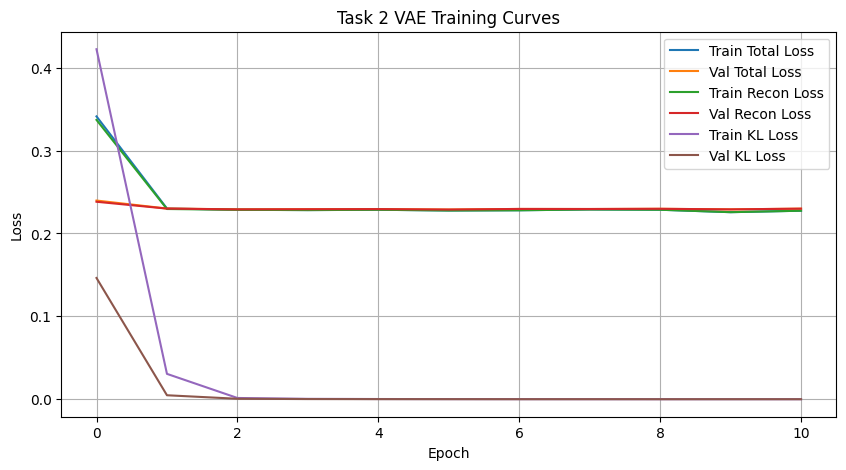

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Total Loss")
plt.plot(val_losses, label="Val Total Loss")
plt.plot(train_recon_losses, label="Train Recon Loss")
plt.plot(val_recon_losses, label="Val Recon Loss")
plt.plot(train_kl_losses, label="Train KL Loss")
plt.plot(val_kl_losses, label="Val KL Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Task 2 VAE Training Curves")
plt.legend()
plt.grid(True)
plt.show()

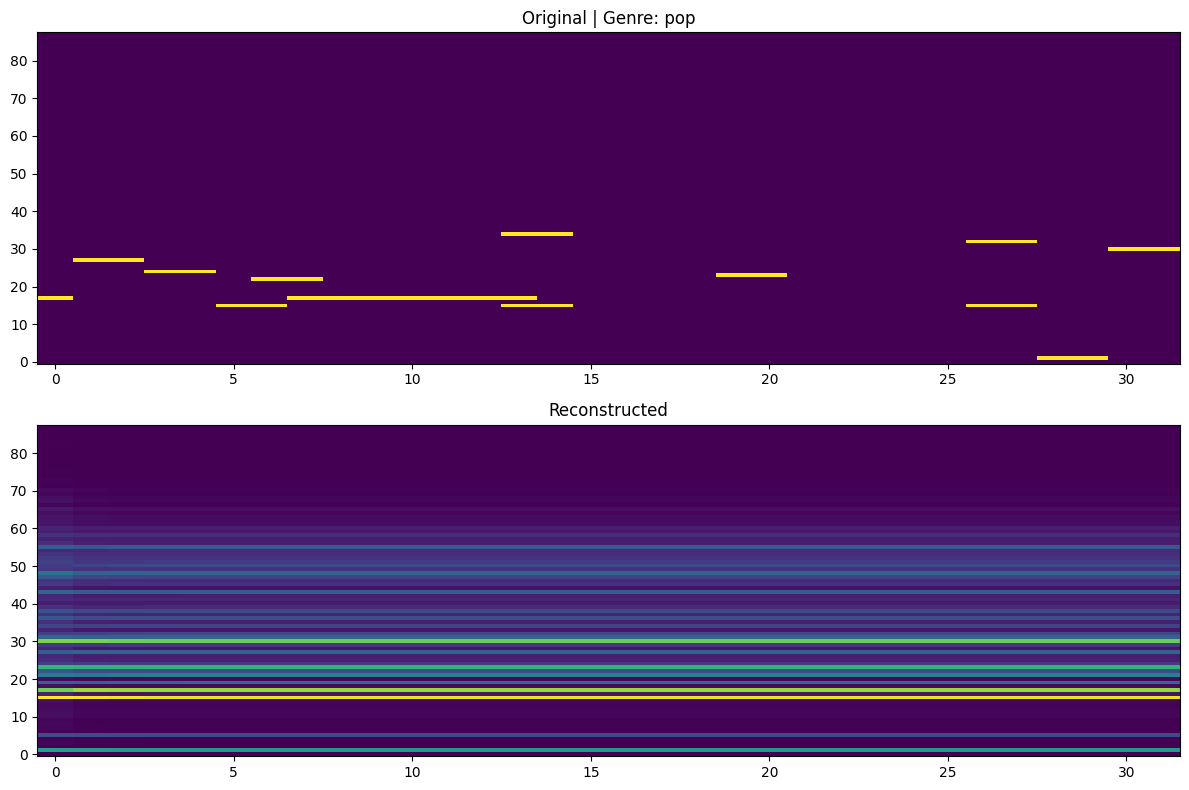

In [57]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

x_batch, g_batch = next(iter(test_loader))
x_batch = x_batch.to(device)
g_batch = g_batch.to(device)

with torch.no_grad():
    logits, mu, logvar = model(x_batch, g_batch)
    recon_batch = torch.sigmoid(logits)

original = x_batch[0].cpu().numpy()
reconstructed = recon_batch[0].cpu().numpy()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
axes[0].imshow(original.T, aspect='auto', origin='lower')
axes[0].set_title(f"Original | Genre: {id_to_genre[int(g_batch[0].cpu())]}")
axes[1].imshow(reconstructed.T, aspect='auto', origin='lower')
axes[1].set_title("Reconstructed")
plt.tight_layout()
plt.show()

In [58]:
def binarize_pianoroll(piano_roll, threshold=0.5, max_polyphony=6, min_keep_prob=0.35):
    pr = np.array(piano_roll, copy=True)
    binary_roll = np.zeros_like(pr, dtype=np.int32)

    for t in range(pr.shape[0]):
        row = pr[t]
        active = np.where(row >= threshold)[0]

        if len(active) == 0:
            best_idx = np.argmax(row)
            if row[best_idx] >= min_keep_prob:
                active = np.array([best_idx])

        if len(active) > max_polyphony:
            active = active[np.argsort(row[active])[-max_polyphony:]]

        binary_roll[t, active] = 1

    return binary_roll


def pianoroll_to_midi(piano_roll, output_path, fs=FS, min_pitch=MIN_PITCH,
                      threshold=0.5, max_polyphony=6, min_keep_prob=0.35):

    binary_roll = binarize_pianoroll(
        piano_roll,
        threshold=threshold,
        max_polyphony=max_polyphony,
        min_keep_prob=min_keep_prob
    )

    pm = pretty_midi.PrettyMIDI()
    instrument = pretty_midi.Instrument(program=0)
    time_per_step = 1.0 / fs

    for pitch_idx in range(binary_roll.shape[1]):
        pitch = pitch_idx + min_pitch
        note_on = None

        for t in range(binary_roll.shape[0]):
            value = binary_roll[t, pitch_idx]

            if value == 1 and note_on is None:
                note_on = t * time_per_step

            elif value == 0 and note_on is not None:
                note_off = t * time_per_step
                if note_off > note_on:
                    instrument.notes.append(
                        pretty_midi.Note(
                            velocity=100,
                            pitch=pitch,
                            start=note_on,
                            end=note_off
                        )
                    )
                note_on = None

        if note_on is not None:
            note_off = binary_roll.shape[0] * time_per_step
            if note_off > note_on:
                instrument.notes.append(
                    pretty_midi.Note(
                        velocity=100,
                        pitch=pitch,
                        start=note_on,
                        end=note_off
                    )
                )

    pm.instruments.append(instrument)
    pm.write(output_path)

    return binary_roll

In [59]:
def generate_vae_samples(model, genre_id, num_samples=2, seq_len=SEQ_LEN):
    model.eval()
    genre_ids = torch.full((num_samples,), genre_id, dtype=torch.long, device=device)
    z = torch.randn(num_samples, LATENT_DIM, device=device)

    with torch.no_grad():
        samples = torch.sigmoid(model.decode(z, genre_ids, seq_len)).cpu().numpy()

    return samples


sampled_dir = os.path.join(OUTPUT_DIR, "generated_midis_task2")
os.makedirs(sampled_dir, exist_ok=True)

saved_paths = []

for genre_name, genre_id in genre_to_id.items():
    samples = generate_vae_samples(model, genre_id, num_samples=2)

    for i, sample in enumerate(samples):
        out_path = os.path.join(sampled_dir, f"{genre_name}_sample_{i+1}.mid")
        pianoroll_to_midi(sample, out_path, threshold=0.5, max_polyphony=6)
        saved_paths.append(out_path)

print("Saved", len(saved_paths), "generated MIDI files")
for p in saved_paths:
    print(p)

Saved 8 generated MIDI files
/content/outputs_task2_vae/generated_midis_task2/classical_sample_1.mid
/content/outputs_task2_vae/generated_midis_task2/classical_sample_2.mid
/content/outputs_task2_vae/generated_midis_task2/jazz_sample_1.mid
/content/outputs_task2_vae/generated_midis_task2/jazz_sample_2.mid
/content/outputs_task2_vae/generated_midis_task2/pop_sample_1.mid
/content/outputs_task2_vae/generated_midis_task2/pop_sample_2.mid
/content/outputs_task2_vae/generated_midis_task2/rock_sample_1.mid
/content/outputs_task2_vae/generated_midis_task2/rock_sample_2.mid


In [60]:
def latent_interpolation(model, x1, g1, x2, g2, steps=5, seq_len=SEQ_LEN):
    model.eval()

    with torch.no_grad():
        mu1, logvar1 = model.encode(x1, g1)
        mu2, logvar2 = model.encode(x2, g2)

        z1 = mu1
        z2 = mu2

        interpolations = []
        for alpha in np.linspace(0, 1, steps):
            z = (1 - alpha) * z1 + alpha * z2
            logits = model.decode(z, g1, seq_len)
            sample = torch.sigmoid(logits).squeeze(0).cpu().numpy()
            interpolations.append(sample)

    return interpolations


x1 = torch.tensor(test_data[0:1], dtype=torch.float32).to(device)
g1 = torch.tensor(test_labels[0:1], dtype=torch.long).to(device)

x2 = torch.tensor(test_data[10:11], dtype=torch.float32).to(device)
g2 = torch.tensor(test_labels[10:11], dtype=torch.long).to(device)

interp_samples = latent_interpolation(model, x1, g1, x2, g2, steps=5)

interp_dir = os.path.join(OUTPUT_DIR, "latent_interpolation")
os.makedirs(interp_dir, exist_ok=True)

for i, sample in enumerate(interp_samples):
    out_path = os.path.join(interp_dir, f"interp_{i+1}.mid")
    pianoroll_to_midi(sample, out_path, threshold=0.5, max_polyphony=6)

print("Saved interpolation samples to:", interp_dir)

Saved interpolation samples to: /content/outputs_task2_vae/latent_interpolation


In [61]:
def evaluate_vae(model, loader, device, pos_weight, beta):
    model.eval()
    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0

    with torch.no_grad():
        for x, g in loader:
            x = x.to(device)
            g = g.to(device)

            logits, mu, logvar = model(x, g)
            loss, recon, kl = vae_loss_function(logits, x, mu, logvar, pos_weight, beta)

            total_loss += loss.item()
            total_recon += recon.item()
            total_kl += kl.item()

    n = len(loader)
    return total_loss / n, total_recon / n, total_kl / n


test_total, test_recon, test_kl = evaluate_vae(model, test_loader, device, pos_weight, BETA_MAX)

print("Test Total Loss:", round(test_total, 4))
print("Test Recon Loss:", round(test_recon, 4))
print("Test KL Loss:", round(test_kl, 4))

Test Total Loss: 0.232
Test Recon Loss: 0.2319
Test KL Loss: 0.0001


In [62]:
def compute_pitch_class_histogram(piano_roll, min_pitch=MIN_PITCH):
    piano_roll = (piano_roll > 0).astype(np.int32)
    pitch_activity = np.sum(piano_roll, axis=0).astype(np.float64)

    hist = np.zeros(12, dtype=np.float64)
    for i, value in enumerate(pitch_activity):
        midi_pitch = min_pitch + i
        pitch_class = midi_pitch % 12
        hist[pitch_class] += value

    total = np.sum(hist)
    if total > 0:
        hist /= total

    return hist


def histogram_distance(h1, h2):
    return np.sum(np.abs(h1 - h2))


def rhythm_diversity_score(piano_roll):
    piano_roll = (piano_roll > 0).astype(np.int32)
    note_counts = np.sum(piano_roll, axis=1)
    unique_durations = len(np.unique(note_counts))
    total_notes = np.sum(note_counts)
    if total_notes == 0:
        return 0.0
    return unique_durations / total_notes


def repetition_ratio(piano_roll, pattern_len=4):
    piano_roll = (piano_roll > 0).astype(np.int32)
    patterns = []

    for i in range(len(piano_roll) - pattern_len + 1):
        pattern = tuple(piano_roll[i:i+pattern_len].flatten())
        patterns.append(pattern)

    if len(patterns) == 0:
        return 0.0

    unique_patterns = len(set(patterns))
    repeated_patterns = len(patterns) - unique_patterns
    return repeated_patterns / len(patterns)

In [63]:
metric_rows = []

for genre_name, genre_id in genre_to_id.items():
    gen_seq = generate_vae_samples(model, genre_id=genre_id, num_samples=1)[0]
    gen_binary = binarize_pianoroll(gen_seq, threshold=0.5, max_polyphony=6)

    genre_indices = np.where(test_labels == genre_id)[0]
    if len(genre_indices) > 0:
        real_seq = test_data[genre_indices[0]]
    else:
        real_seq = test_data[0]

    real_hist = compute_pitch_class_histogram(real_seq)
    gen_hist = compute_pitch_class_histogram(gen_binary)

    metric_rows.append({
        "Genre": genre_name,
        "Pitch Histogram Distance": float(histogram_distance(real_hist, gen_hist)),
        "Rhythm Diversity": float(rhythm_diversity_score(gen_binary)),
        "Repetition Ratio": float(repetition_ratio(gen_binary))
    })

genre_metrics = pd.DataFrame(metric_rows)
print(genre_metrics)

       Genre  Pitch Histogram Distance  Rhythm Diversity  Repetition Ratio
0  classical                  1.862471          0.060606          0.931034
1       jazz                  1.636364          0.031250          0.965517
2        pop                  1.406061          0.060606          0.931034
3       rock                  1.702106          0.060606          0.931034


In [64]:
task2_results = pd.DataFrame([
    {
        "Model": "Task 2 Music VAE",
        "Test Total Loss": float(test_total),
        "Test Recon Loss": float(test_recon),
        "Test KL Loss": float(test_kl),
        "Mean Pitch Histogram Distance": float(genre_metrics["Pitch Histogram Distance"].mean()),
        "Mean Rhythm Diversity": float(genre_metrics["Rhythm Diversity"].mean()),
        "Mean Repetition Ratio": float(genre_metrics["Repetition Ratio"].mean())
    }
])

task2_csv = os.path.join(OUTPUT_DIR, "task2_metrics.csv")
task2_results.to_csv(task2_csv, index=False)

print(task2_results)
print("Saved:", task2_csv)

              Model  Test Total Loss  Test Recon Loss  Test KL Loss  \
0  Task 2 Music VAE         0.231958         0.231944      0.000136   

   Mean Pitch Histogram Distance  Mean Rhythm Diversity  Mean Repetition Ratio  
0                        1.65175               0.053267               0.939655  
Saved: /content/outputs_task2_vae/task2_metrics.csv


In [65]:
task1_csv = "/content/outputs_task1_fixed/task1_metrics.csv"

if os.path.exists(task1_csv):
    task1_df = pd.read_csv(task1_csv)
    comparison_df = pd.concat([task1_df, task2_results], ignore_index=True)
    comparison_path = os.path.join(OUTPUT_DIR, "task1_vs_task2_comparison.csv")
    comparison_df.to_csv(comparison_path, index=False)
    print(comparison_df)
    print("Saved comparison to:", comparison_path)
else:
    print("Task 1 CSV not found. Update the path if needed.")

Task 1 CSV not found. Update the path if needed.


In [66]:
!zip -r /content/task2_vae_outputs.zip /content/outputs_task2_vae > /dev/null
print("Created: /content/task2_vae_outputs.zip")

Created: /content/task2_vae_outputs.zip


**TASK-3**




In [67]:
# =========================
# =========================
from dataclasses import dataclass
import os
import math
import json
import random
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

@dataclass
class Task3Config:
    data_path: str = "task3_tokenized_sequences.pt"
    output_dir: str = "/content/outputs_task3_transformer"

    pad_token_id: int = 0
    bos_token_id: int = 1
    eos_token_id: int = 2
    unk_token_id: int = 3

    max_seq_len: int = 256
    min_train_tokens: int = 32
    batch_size: int = 16
    num_workers: int = 2

    d_model: int = 256
    n_heads: int = 8
    n_layers: int = 6
    d_ff: int = 1024
    dropout: float = 0.1
    label_smoothing: float = 0.05

    lr: float = 3e-4
    min_lr: float = 1e-5
    weight_decay: float = 1e-4
    epochs: int = 20
    warmup_steps: int = 400
    grad_clip: float = 1.0
    patience: int = 5

    gen_length: int = 384
    min_gen_len: int = 128
    prompt_len: int = 24
    temperature: float = 0.95
    top_k: int = 10
    top_p: float = 0.92
    repetition_penalty: float = 1.15
    no_repeat_ngram_size: int = 4

    seed: int = 42

cfg = Task3Config()
os.makedirs(cfg.output_dir, exist_ok=True)

# deterministic setup
random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
torch.cuda.manual_seed_all(cfg.seed)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
print(cfg)

Using device: cuda
Task3Config(data_path='task3_tokenized_sequences.pt', output_dir='/content/outputs_task3_transformer', pad_token_id=0, bos_token_id=1, eos_token_id=2, unk_token_id=3, max_seq_len=256, min_train_tokens=32, batch_size=16, num_workers=2, d_model=256, n_heads=8, n_layers=6, d_ff=1024, dropout=0.1, label_smoothing=0.05, lr=0.0003, min_lr=1e-05, weight_decay=0.0001, epochs=20, warmup_steps=400, grad_clip=1.0, patience=5, gen_length=384, min_gen_len=128, prompt_len=24, temperature=0.95, top_k=10, top_p=0.92, repetition_penalty=1.15, no_repeat_ngram_size=4, seed=42)


In [68]:
# -------------------------
# Event tokenization
# -------------------------
SPECIAL_TOKENS = ["<PAD>", "<BOS>", "<EOS>", "<UNK>"]

def emit_time_shift(tokens, shift, max_shift=16):
    while shift > 0:
        step = min(shift, max_shift)
        tokens.append(f"TIME_SHIFT_{step}")
        shift -= step

def pianoroll_to_event_tokens(seq):
    """
    Converts a binary piano-roll sequence (T, P) into sparse note on/off + time-shift events.
    """
    seq = (seq > 0).astype(np.uint8)
    T, P = seq.shape

    tokens = []
    prev = np.zeros(P, dtype=np.uint8)
    pending_shift = 0

    for t in range(T):
        cur = seq[t]
        note_offs = np.where((prev == 1) & (cur == 0))[0].tolist()
        note_ons  = np.where((prev == 0) & (cur == 1))[0].tolist()

        if len(note_offs) == 0 and len(note_ons) == 0:
            pending_shift += 1
        else:
            if pending_shift > 0:
                emit_time_shift(tokens, pending_shift)
                pending_shift = 0

            for p in sorted(note_offs):
                tokens.append(f"NOTE_OFF_{p}")
            for p in sorted(note_ons):
                tokens.append(f"NOTE_ON_{p}")

        prev = cur.copy()

    if pending_shift > 0:
        emit_time_shift(tokens, pending_shift)

    for p in np.where(prev == 1)[0].tolist():
        tokens.append(f"NOTE_OFF_{p}")

    return tokens

def build_event_token_dataset(all_sequences, all_labels, min_freq=1):
    tokenized_events = []
    genre_ids = []

    for seq, genre in zip(all_sequences, all_labels):
        events = pianoroll_to_event_tokens(seq)
        tokenized_events.append(events)
        genre_ids.append(int(genre))

    counter = Counter()
    for events in tokenized_events:
        counter.update(events)

    vocab = {tok: i for i, tok in enumerate(SPECIAL_TOKENS)}
    for tok, freq in counter.items():
        if freq >= min_freq and tok not in vocab:
            vocab[tok] = len(vocab)

    id_to_token = {i: t for t, i in vocab.items()}

    records = []
    for events, genre in zip(tokenized_events, genre_ids):
        token_ids = [vocab["<BOS>"]] + [vocab.get(ev, vocab["<UNK>"]) for ev in events] + [vocab["<EOS>"]]
        if len(token_ids) >= cfg.min_train_tokens:
            records.append({"tokens": token_ids, "genre": genre})

    return records, vocab, id_to_token

records, vocab, id_to_token = build_event_token_dataset(all_sequences, all_labels, min_freq=1)

cfg.pad_token_id = vocab["<PAD>"]
cfg.bos_token_id = vocab["<BOS>"]
cfg.eos_token_id = vocab["<EOS>"]
cfg.unk_token_id = vocab["<UNK>"]
cfg.vocab_size = len(vocab)
cfg.num_genres = int(len(np.unique(all_labels)))

payload = {"records": records, "vocab": vocab, "id_to_token": id_to_token}
torch.save(payload, cfg.data_path)

print("Saved tokenized dataset to:", cfg.data_path)
print("Records:", len(records))
print("Vocab size:", cfg.vocab_size)
print("Genres:", cfg.num_genres)

Saved tokenized dataset to: task3_tokenized_sequences.pt
Records: 1660
Vocab size: 172
Genres: 4


In [69]:
# -------------------------
# Dataset and model
# -------------------------
class MusicTokenDataset(Dataset):
    def __init__(self, records, max_seq_len, pad_token_id):
        self.records = records
        self.max_seq_len = max_seq_len
        self.pad_token_id = pad_token_id

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        tokens = rec["tokens"][: self.max_seq_len]
        genre = rec["genre"]
        return {
            "tokens": torch.tensor(tokens, dtype=torch.long),
            "genre": torch.tensor(genre, dtype=torch.long)
        }

def causal_lm_collate(batch, pad_token_id):
    token_seqs = [b["tokens"] for b in batch]
    genres = torch.stack([b["genre"] for b in batch])

    max_len = max(len(x) for x in token_seqs)
    padded = torch.full((len(batch), max_len), pad_token_id, dtype=torch.long)

    for i, seq in enumerate(token_seqs):
        padded[i, :len(seq)] = seq

    inputs = padded[:, :-1]
    targets = padded[:, 1:]
    padding_mask = inputs.eq(pad_token_id)

    return inputs, targets, genres, padding_mask

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=4096):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0), persistent=False)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class MusicTransformer(nn.Module):
    def __init__(
        self,
        vocab_size,
        num_genres,
        d_model=256,
        n_heads=8,
        n_layers=6,
        d_ff=1024,
        dropout=0.1,
        max_seq_len=512,
        pad_token_id=0
    ):
        super().__init__()
        self.pad_token_id = pad_token_id
        self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=pad_token_id)
        self.genre_emb = nn.Embedding(num_genres, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len=max_seq_len + 8)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(d_model)
        self.output_head = nn.Linear(d_model, vocab_size)

    def forward(self, input_ids, genre_ids, padding_mask=None):
        x = self.token_emb(input_ids)
        g = self.genre_emb(genre_ids).unsqueeze(1)
        x = x + g
        x = self.pos_enc(x)
        x = self.dropout(x)

        seq_len = input_ids.size(1)
        causal_mask = torch.triu(
            torch.full((seq_len, seq_len), float("-inf"), device=input_ids.device),
            diagonal=1
        )

        h = self.transformer(x, mask=causal_mask, src_key_padding_mask=padding_mask)
        h = self.norm(h)
        logits = self.output_head(h)
        return logits

In [70]:
# -------------------------
# Data split, loaders, optimizer, training utilities
# -------------------------
payload = torch.load(cfg.data_path)
records = payload["records"]
vocab = payload["vocab"]
id_to_token = payload["id_to_token"]

records = [r for r in records if len(r["tokens"]) >= cfg.min_train_tokens]

rng = np.random.default_rng(cfg.seed)
by_genre = defaultdict(list)
for r in records:
    by_genre[int(r["genre"])].append(r)

train_records, val_records, test_records = [], [], []
for gid, recs in by_genre.items():
    recs = recs.copy()
    rng.shuffle(recs)
    n = len(recs)
    train_end = int(0.8 * n)
    val_end = int(0.9 * n)

    train_records.extend(recs[:train_end])
    val_records.extend(recs[train_end:val_end])
    test_records.extend(recs[val_end:])

rng.shuffle(train_records)
rng.shuffle(val_records)
rng.shuffle(test_records)

train_ds = MusicTokenDataset(train_records, cfg.max_seq_len, cfg.pad_token_id)
val_ds   = MusicTokenDataset(val_records, cfg.max_seq_len, cfg.pad_token_id)
test_ds  = MusicTokenDataset(test_records, cfg.max_seq_len, cfg.pad_token_id)

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    collate_fn=lambda b: causal_lm_collate(b, cfg.pad_token_id)
)
val_loader = DataLoader(
    val_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    collate_fn=lambda b: causal_lm_collate(b, cfg.pad_token_id)
)
test_loader = DataLoader(
    test_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    collate_fn=lambda b: causal_lm_collate(b, cfg.pad_token_id)
)

print(f"Train / Val / Test sequences: {len(train_ds)} / {len(val_ds)} / {len(test_ds)}")

model = MusicTransformer(
    vocab_size=len(vocab),
    num_genres=cfg.num_genres,
    d_model=cfg.d_model,
    n_heads=cfg.n_heads,
    n_layers=cfg.n_layers,
    d_ff=cfg.d_ff,
    dropout=cfg.dropout,
    max_seq_len=cfg.max_seq_len,
    pad_token_id=cfg.pad_token_id
).to(DEVICE)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=cfg.lr,
    weight_decay=cfg.weight_decay,
    betas=(0.9, 0.95)
)

steps_per_epoch = max(1, len(train_loader))
total_steps = cfg.epochs * steps_per_epoch

def lr_lambda(step):
    step = max(1, step)
    if step < cfg.warmup_steps:
        return step / max(1, cfg.warmup_steps)
    progress = (step - cfg.warmup_steps) / max(1, total_steps - cfg.warmup_steps)
    cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
    floor = cfg.min_lr / cfg.lr
    return max(floor, cosine)

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

criterion = nn.CrossEntropyLoss(
    ignore_index=cfg.pad_token_id,
    label_smoothing=cfg.label_smoothing
)

def run_epoch(model, loader, train=True):
    model.train(train)
    total_loss = 0.0
    total_tokens = 0

    for inputs, targets, genres, padding_mask in loader:
        inputs = inputs.to(DEVICE)
        targets = targets.to(DEVICE)
        genres = genres.to(DEVICE)
        padding_mask = padding_mask.to(DEVICE)

        with torch.set_grad_enabled(train):
            logits = model(inputs, genres, padding_mask=padding_mask)
            loss = criterion(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))

        valid_tokens = (targets != cfg.pad_token_id).sum().item()
        total_loss += loss.item() * valid_tokens
        total_tokens += valid_tokens

        if train:
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            optimizer.step()
            scheduler.step()

    mean_nll = total_loss / max(1, total_tokens)
    ppl = float(math.exp(min(mean_nll, 20)))
    return mean_nll, ppl

Train / Val / Test sequences: 1326 / 166 / 168


/tmp/ipykernel_620/844693562.py:79: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:431: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  src_key_padding_mask = F._canonical_mask(


{'epoch': 1, 'train_nll': 4.699246907279104, 'train_ppl': 109.86440320723649, 'val_nll': 3.9265153005128406, 'val_ppl': 50.72989087655146, 'lr': 6.225e-05}
{'epoch': 2, 'train_nll': 3.649583949878565, 'train_ppl': 38.45866198902666, 'val_nll': 3.397521164379908, 'val_ppl': 29.88991595195077, 'lr': 0.0001245}
{'epoch': 3, 'train_nll': 3.291543895015859, 'train_ppl': 26.884338227262024, 'val_nll': 3.161480820759424, 'val_ppl': 23.605525612749336, 'lr': 0.00018675}
{'epoch': 4, 'train_nll': 3.0446908317800077, 'train_ppl': 21.003536572948853, 'val_nll': 2.8663162354202423, 'val_ppl': 17.572167098331988, 'lr': 0.000249}
{'epoch': 5, 'train_nll': 2.803455319982258, 'train_ppl': 16.501566569112565, 'val_nll': 2.6606063336049335, 'val_ppl': 14.304960047662203, 'lr': 0.0002998951057182598}
{'epoch': 6, 'train_nll': 2.6218540503553616, 'train_ppl': 13.761213931162668, 'val_nll': 2.53934356820033, 'val_ppl': 12.671350362853884, 'lr': 0.0002955443589413994}
{'epoch': 7, 'train_nll': 2.49504483681

/tmp/ipykernel_620/844693562.py:79: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)



Best model: /content/outputs_task3_transformer/best_task3_transformer.pt
History saved to: /content/outputs_task3_transformer/task3_training_history.csv
Task 3 Test NLL: 2.1371
Task 3 Test Perplexity: 8.4752


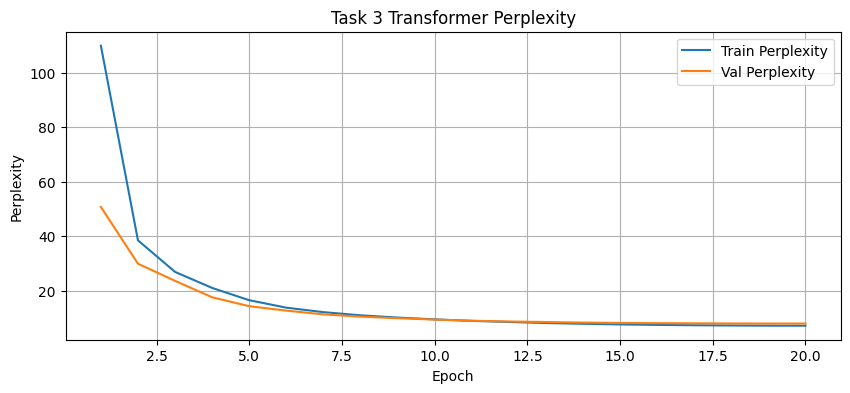

In [71]:
# -------------------------
# Training loop with checkpointing + perplexity report
# -------------------------
history = []
best_val_ppl = float("inf")
best_path = os.path.join(cfg.output_dir, "best_task3_transformer.pt")
patience_counter = 0

for epoch in range(1, cfg.epochs + 1):
    train_nll, train_ppl = run_epoch(model, train_loader, train=True)
    val_nll, val_ppl = run_epoch(model, val_loader, train=False)

    row = {
        "epoch": epoch,
        "train_nll": train_nll,
        "train_ppl": train_ppl,
        "val_nll": val_nll,
        "val_ppl": val_ppl,
        "lr": optimizer.param_groups[0]["lr"]
    }
    history.append(row)
    print(row)

    if val_ppl < best_val_ppl:
        best_val_ppl = val_ppl
        torch.save(model.state_dict(), best_path)
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= cfg.patience:
        print("Early stopping triggered.")
        break

history_df = pd.DataFrame(history)
history_csv = os.path.join(cfg.output_dir, "task3_training_history.csv")
history_df.to_csv(history_csv, index=False)

best_model = MusicTransformer(
    vocab_size=len(vocab),
    num_genres=cfg.num_genres,
    d_model=cfg.d_model,
    n_heads=cfg.n_heads,
    n_layers=cfg.n_layers,
    d_ff=cfg.d_ff,
    dropout=cfg.dropout,
    max_seq_len=cfg.max_seq_len,
    pad_token_id=cfg.pad_token_id
).to(DEVICE)
best_model.load_state_dict(torch.load(best_path, map_location=DEVICE))

test_nll, test_ppl = run_epoch(best_model, test_loader, train=False)

print("\nBest model:", best_path)
print("History saved to:", history_csv)
print(f"Task 3 Test NLL: {test_nll:.4f}")
print(f"Task 3 Test Perplexity: {test_ppl:.4f}")

plt.figure(figsize=(10, 4))
plt.plot(history_df["epoch"], history_df["train_ppl"], label="Train Perplexity")
plt.plot(history_df["epoch"], history_df["val_ppl"], label="Val Perplexity")
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.title("Task 3 Transformer Perplexity")
plt.grid(True)
plt.legend()
plt.show()

In [72]:
# -------------------------
# Autoregressive generation + MIDI export
# -------------------------
def top_k_top_p_filtering(logits, top_k=0, top_p=1.0):
    logits = logits.clone()

    if top_k > 0:
        top_k = min(top_k, logits.size(-1))
        values, _ = torch.topk(logits, top_k)
        cutoff = values[..., -1]
        logits[logits < cutoff] = -float("inf")

    if top_p < 1.0:
        sorted_logits, sorted_indices = torch.sort(logits, descending=True)
        sorted_probs = F.softmax(sorted_logits, dim=-1)
        cumulative_probs = torch.cumsum(sorted_probs, dim=-1)
        sorted_indices_to_remove = cumulative_probs > top_p
        sorted_indices_to_remove[1:] = sorted_indices_to_remove[:-1].clone()
        sorted_indices_to_remove[0] = False
        remove_ids = sorted_indices[sorted_indices_to_remove]
        logits[remove_ids] = -float("inf")

    return logits

def apply_no_repeat_ngram(logits, tokens, no_repeat_ngram_size):
    if no_repeat_ngram_size <= 1 or len(tokens) < no_repeat_ngram_size - 1:
        return logits

    prefix = tuple(tokens[-(no_repeat_ngram_size - 1):])
    banned = set()

    for i in range(len(tokens) - no_repeat_ngram_size + 1):
        ngram = tokens[i:i + no_repeat_ngram_size]
        if tuple(ngram[:-1]) == prefix:
            banned.add(ngram[-1])

    for tok in banned:
        logits[tok] = -float("inf")
    return logits

@torch.no_grad()
def generate_sequence(
    model,
    genre_id,
    prompt=None,
    max_new_tokens=384,
    min_new_tokens=128,
    temperature=1.0,
    top_k=10,
    top_p=0.92,
    repetition_penalty=1.15,
    no_repeat_ngram_size=4
):
    model.eval()

    if prompt is None or len(prompt) == 0:
        tokens = [cfg.bos_token_id]
    else:
        tokens = prompt[:]
        if tokens[0] != cfg.bos_token_id:
            tokens = [cfg.bos_token_id] + tokens

    start_len = len(tokens)

    for _ in range(max_new_tokens):
        x = torch.tensor(tokens[-cfg.max_seq_len:], dtype=torch.long, device=DEVICE).unsqueeze(0)
        g = torch.tensor([genre_id], dtype=torch.long, device=DEVICE)
        padding_mask = torch.zeros_like(x, dtype=torch.bool)

        logits = model(x, g, padding_mask=padding_mask)[0, -1]
        logits = logits / max(temperature, 1e-6)

        for t in set(tokens[-96:]):
            if logits[t] > 0:
                logits[t] /= repetition_penalty
            else:
                logits[t] *= repetition_penalty

        if (len(tokens) - start_len) < min_new_tokens:
            logits[cfg.eos_token_id] = -float("inf")

        logits = apply_no_repeat_ngram(logits, tokens, no_repeat_ngram_size)
        logits = top_k_top_p_filtering(logits, top_k=top_k, top_p=top_p)
        probs = F.softmax(logits, dim=-1)

        if torch.isnan(probs).any() or torch.isinf(probs).any() or probs.sum() <= 0:
            probs = torch.ones_like(probs) / probs.numel()

        next_token = torch.multinomial(probs, num_samples=1).item()
        tokens.append(next_token)
        if next_token == cfg.eos_token_id:
            break

    if tokens[-1] != cfg.eos_token_id:
        tokens.append(cfg.eos_token_id)

    return tokens

def build_prompt_for_genre(records, genre_id, prompt_len=24):
    candidates = [r for r in records if int(r["genre"]) == int(genre_id) and len(r["tokens"]) > prompt_len + 2]
    if len(candidates) == 0:
        return [cfg.bos_token_id]
    rec = max(candidates, key=lambda r: len(r["tokens"]))
    prompt = [t for t in rec["tokens"][:prompt_len] if t != cfg.eos_token_id]
    if len(prompt) == 0 or prompt[0] != cfg.bos_token_id:
        prompt = [cfg.bos_token_id] + prompt
    return prompt

def event_tokens_to_pianoroll(token_ids, id_to_token, pitch_dim=PITCH_DIM):
    active = np.zeros(pitch_dim, dtype=np.uint8)
    steps = []

    def push_step():
        steps.append(active.copy())

    for tid in token_ids:
        tok = id_to_token.get(int(tid), "<UNK>")
        if tok in ("<PAD>", "<BOS>", "<UNK>"):
            continue
        if tok == "<EOS>":
            break
        if tok.startswith("TIME_SHIFT_"):
            shift = int(tok.split("_")[-1])
            for _ in range(max(1, shift)):
                push_step()
        elif tok.startswith("NOTE_ON_"):
            p = int(tok.split("_")[-1])
            if 0 <= p < pitch_dim:
                active[p] = 1
        elif tok.startswith("NOTE_OFF_"):
            p = int(tok.split("_")[-1])
            if 0 <= p < pitch_dim:
                active[p] = 0

    if len(steps) == 0:
        steps.append(active.copy())

    pr = np.stack(steps, axis=0).astype(np.float32)
    return pr

task3_midi_dir = os.path.join(cfg.output_dir, "generated_midis_task3")
task3_json_dir = os.path.join(cfg.output_dir, "generated_json_task3")
os.makedirs(task3_midi_dir, exist_ok=True)
os.makedirs(task3_json_dir, exist_ok=True)

available_genres = sorted(list(set(int(r["genre"]) for r in train_records)))
genre_names_task3 = id_to_genre if "id_to_genre" in globals() else {gid: f"genre_{gid}" for gid in available_genres}

requested_genres = [available_genres[i % len(available_genres)] for i in range(10)]
task3_samples = []

for i, gid in enumerate(requested_genres, start=1):
    prompt = build_prompt_for_genre(train_records, gid, prompt_len=cfg.prompt_len)
    seq = generate_sequence(
        best_model,
        genre_id=gid,
        prompt=prompt,
        max_new_tokens=cfg.gen_length,
        min_new_tokens=cfg.min_gen_len,
        temperature=cfg.temperature,
        top_k=cfg.top_k,
        top_p=cfg.top_p,
        repetition_penalty=cfg.repetition_penalty,
        no_repeat_ngram_size=cfg.no_repeat_ngram_size,
    )

    pr = event_tokens_to_pianoroll(seq, id_to_token, pitch_dim=PITCH_DIM)
    genre_name = genre_names_task3.get(gid, f"genre_{gid}")
    midi_path = os.path.join(task3_midi_dir, f"task3_sample_{i:02d}_{genre_name}.mid")
    json_path = os.path.join(task3_json_dir, f"task3_sample_{i:02d}_{genre_name}.json")

    pianoroll_to_midi(pr, midi_path, fs=FS, min_pitch=MIN_PITCH, threshold=0.5, max_polyphony=6)

    record = {
        "sample_id": i,
        "genre_id": int(gid),
        "genre_name": genre_name,
        "prompt_length": len(prompt),
        "num_tokens": len(seq),
        "midi_path": midi_path,
        "tokens": seq,
        "token_text": [id_to_token.get(t, "<UNK>") for t in seq]
    }
    task3_samples.append(record)

    with open(json_path, "w") as f:
        json.dump(record, f, indent=2)

task3_samples_df = pd.DataFrame([
    {
        "sample_id": s["sample_id"],
        "genre": s["genre_name"],
        "prompt_length": s["prompt_length"],
        "num_tokens": s["num_tokens"],
        "midi_path": s["midi_path"],
    }
    for s in task3_samples
])

print("Generated MIDI files:", len(task3_samples_df))
task3_samples_df

Generated MIDI files: 10


,sample_id,genre,prompt_length,num_tokens,midi_path
0,1,classical,24,154,/content/outputs_task3_transformer/generated_m...
1,2,jazz,24,155,/content/outputs_task3_transformer/generated_m...
2,3,pop,24,155,/content/outputs_task3_transformer/generated_m...
3,4,rock,24,153,/content/outputs_task3_transformer/generated_m...
4,5,classical,24,153,/content/outputs_task3_transformer/generated_m...
5,6,jazz,24,153,/content/outputs_task3_transformer/generated_m...
6,7,pop,24,156,/content/outputs_task3_transformer/generated_m...
7,8,rock,24,153,/content/outputs_task3_transformer/generated_m...
8,9,classical,24,153,/content/outputs_task3_transformer/generated_m...
9,10,jazz,24,153,/content/outputs_task3_transformer/generated_m...


**Task-4**



**Reinforcement Learning
Human Preference Tuning**


